# BIND 3D: Generated vs. Truth Halo Comparison

Loads pre-generated 3D halo volumes from `run_test_suite_3d.py` and compares them  
with the true simulation targets across five diagnostics:

1. **Mass** — per-channel total mass scatter, histograms, relative error  
2. **Radial profiles** — spherical shells, mean density, gen/truth ratio  
3. **Power spectra** — 3D P(k) monopole via Pylians, log-log ratio  
4. **Shapes** — reduced inertia tensor axis ratios q = b/a, s = c/a, triaxiality T  
5. **Baryon fraction profile** — f_bar(r) = (Gas + Stars) / (DM + Gas + Stars)

**Channels:** `DM_hydro` (0), `Gas` (1), `Stars` (2)  
**Volume:** 128³ voxels | **Box per halo:** 6.25 Mpc/h  
All arrays are in physical units (mass surface/volume density in simulation units).

## 1 — Imports and Configuration

In [1]:
import sys, os
sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2')
os.environ['CUDA_VISIBLE_DEVICES'] = ''   # CPU-only for analysis

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from tqdm.auto import tqdm
from scipy.stats import ks_2samp
import Pk_library as PKL

plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})

# ── Paths ─────────────────────────────────────────────────────────────────────
GEN_ROOT  = Path('/mnt/home/mlee1/ceph/fm3d_testsuite/fm3d_two_head_v2')
DATA_ROOT = Path('/mnt/home/mlee1/ceph/train_data_1024/train_3d')

# ── Physical parameters ───────────────────────────────────────────────────────
BOX_SIZE      = 6.25    # Mpc/h per halo cube
N_PIX         = 128
PIX_SIZE      = BOX_SIZE / N_PIX  # Mpc/h per voxel

# ── Channel metadata ──────────────────────────────────────────────────────────
CHANNEL_NAMES = ['DM_hydro', 'Gas', 'Stars']
CH_COLORS     = ['steelblue', 'tomato', 'goldenrod']
CH_HATCHES    = ['/', '\\', '|']

# ── Cosmological baryon fraction reference (Planck 2018) ─────────────────────
F_BAR_COSMIC  = 0.156   # Omega_b / Omega_m

# ── Analysis settings ─────────────────────────────────────────────────────────
N_RADIAL_BINS = 24
N_VIS         = 6     # halos to show in visual panels

print('Config OK — reading from:')
print(f'  GEN_ROOT  = {GEN_ROOT}')
print(f'  DATA_ROOT = {DATA_ROOT}')

Config OK — reading from:
  GEN_ROOT  = /mnt/home/mlee1/ceph/fm3d_testsuite/fm3d_two_head_v2
  DATA_ROOT = /mnt/home/mlee1/ceph/train_data_1024/train_3d


## 2 — Load Generated Halos and True Targets

In [2]:
def collect_pairs(gen_root: Path, data_root: Path) -> list[tuple[Path, Path]]:
    """Return matched (generated, source) path pairs that exist on both sides."""
    pairs = []
    for sim_dir in sorted(gen_root.glob('sim_*'), key=lambda p: int(p.name.split('_')[1])):
        src_sim = data_root / sim_dir.name
        for gen_file in sorted(sim_dir.glob('halo_*.npz'),
                               key=lambda p: int(p.stem.split('_')[1])):
            src_file = src_sim / gen_file.name
            if src_file.exists():
                pairs.append((gen_file, src_file))
    return pairs


def load_pair(gen_path: Path, src_path: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Load one (generated, truth) pair.

    Returns
    -------
    gen   : (3, D, H, W)  physical units
    truth : (3, D, H, W)  physical units (raw from source .npz)
    params: (35,)         raw simulation parameters
    """
    gen   = np.load(gen_path)['generated'].astype(np.float32)
    d     = np.load(src_path)
    # target is already in physical units (raw simulation output)
    truth = d['target'].astype(np.float32)
    params = d['params'][:35].astype(np.float32)
    return gen, truth, params


# ── Collect all available pairs ────────────────────────────────────────────
pairs = collect_pairs(GEN_ROOT, DATA_ROOT)
print(f'Found {len(pairs)} matched halo pairs across '
      f'{len(set(p[0].parent.name for p in pairs))} simulations')

# Spot-check one pair
g0, t0, p0 = load_pair(*pairs[0])
print(f'\nSample halo:  gen {g0.shape}  truth {t0.shape}')
for ci, ch in enumerate(CHANNEL_NAMES):
    print(f'  {ch:12s}  truth_sum={t0[ci].sum():.3e}  gen_sum={g0[ci].sum():.3e}')

Found 332 matched halo pairs across 14 simulations

Sample halo:  gen (3, 128, 128, 128)  truth (3, 128, 128, 128)
  DM_hydro      truth_sum=8.837e+13  gen_sum=9.952e+13
  Gas           truth_sum=4.589e+13  gen_sum=4.312e+13
  Stars         truth_sum=7.885e+11  gen_sum=3.532e+11


In [3]:
# ── Stream all pairs: collect per-halo statistics ────────────────────────────
# We accumulate lightweight stats (mass, shapes) without holding all volumes.
# A small cache of N_VIS halos is kept for the visual / profile / P(k) panels.

mass_gen   = np.zeros((len(pairs), 3), dtype=np.float64)
mass_truth = np.zeros((len(pairs), 3), dtype=np.float64)

# For visualization / profiles / P(k): keep first N_VIS loaded volumes
vis_gen, vis_truth = [], []

for idx, (gp, sp) in enumerate(tqdm(pairs, desc='Loading pairs')):
    g, t, _ = load_pair(gp, sp)
    mass_gen[idx]   = g.sum(axis=(-3, -2, -1))
    mass_truth[idx] = t.sum(axis=(-3, -2, -1))
    if idx < N_VIS:
        vis_gen.append(g)
        vis_truth.append(t)

vis_gen   = np.stack(vis_gen)    # (N_VIS, 3, D, H, W)
vis_truth = np.stack(vis_truth)  # (N_VIS, 3, D, H, W)

rel_err = (mass_gen - mass_truth) / (mass_truth + 1e-30)

print('\nPer-channel mass relative error  (gen - truth) / truth:')
for ci, ch in enumerate(CHANNEL_NAMES):
    e = rel_err[:, ci]
    print(f'  {ch:12s}  mean={e.mean()*100:+.2f}%  median={np.median(e)*100:+.2f}%  std={e.std()*100:.2f}%')

Loading pairs:   0%|          | 0/332 [00:00<?, ?it/s]


Per-channel mass relative error  (gen - truth) / truth:
  DM_hydro      mean=+8.13%  median=+7.87%  std=4.59%
  Gas           mean=+0.67%  median=-0.36%  std=6.01%
  Stars         mean=-5.14%  median=-24.98%  std=61.35%


## 3 — Mass Comparison

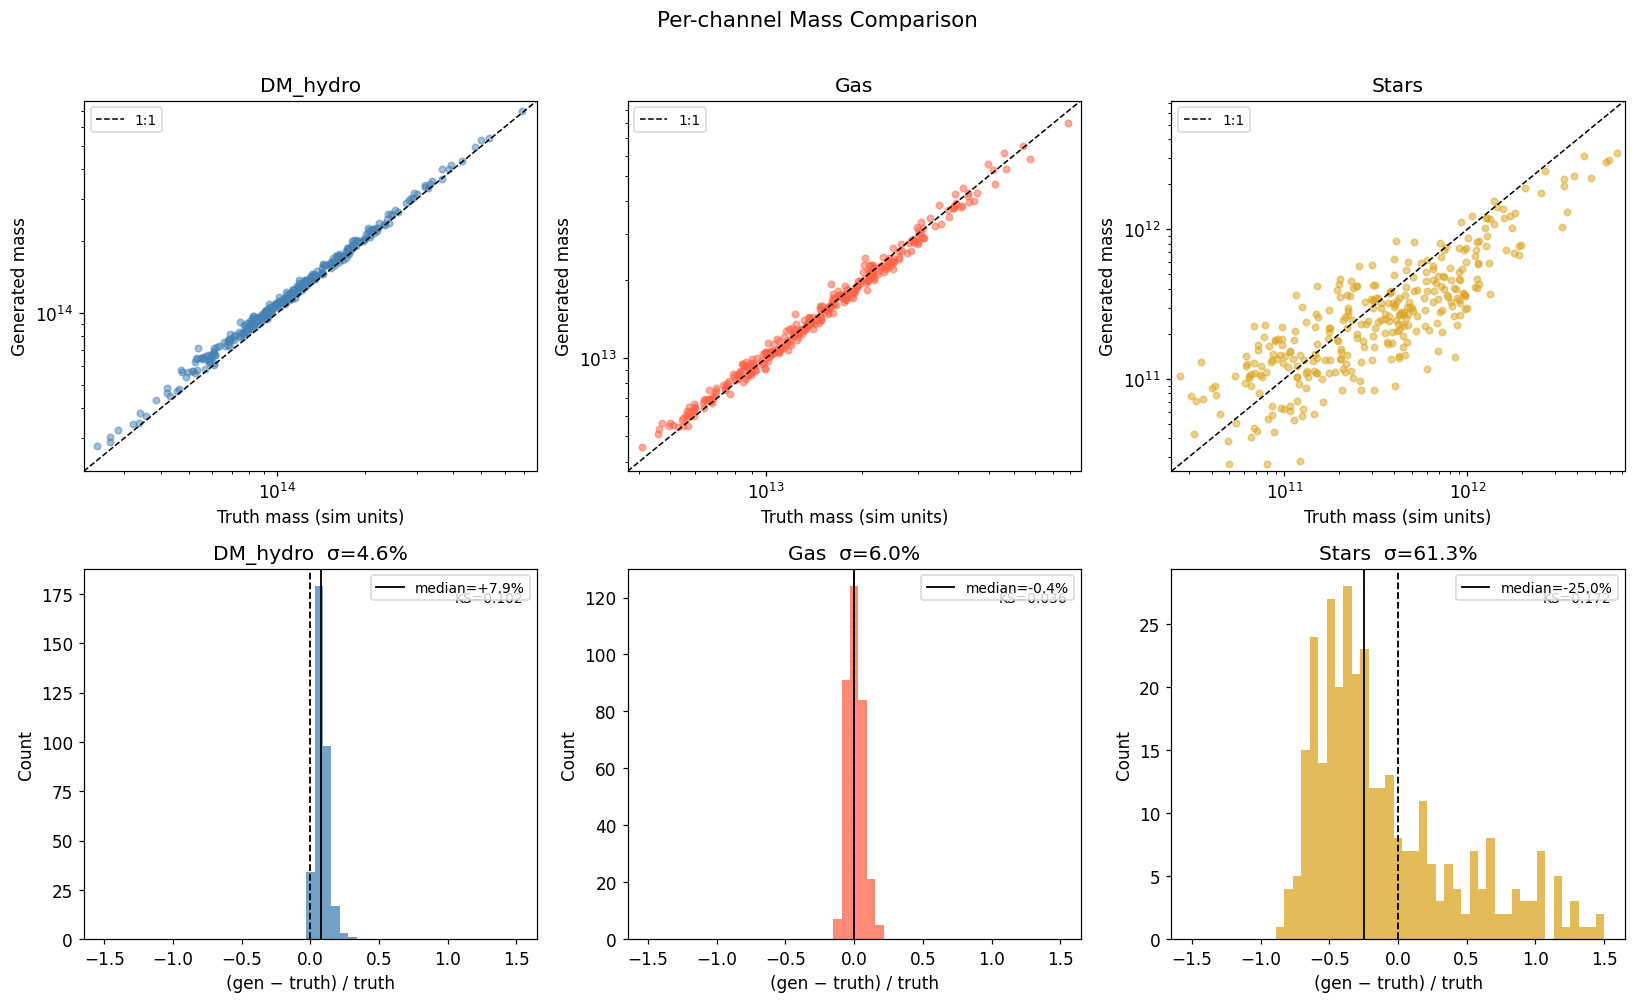

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ci, (ch, col) in enumerate(zip(CHANNEL_NAMES, CH_COLORS)):
    mt = mass_truth[:, ci]
    mg = mass_gen[:, ci]
    er = rel_err[:, ci]

    # ── Top row: scatter truth vs gen ────────────────────────────────────────
    ax = axes[0, ci]
    lo = min(mt.min(), mg.min()) * 0.9
    hi = max(mt.max(), mg.max()) * 1.1
    ax.scatter(mt, mg, alpha=0.5, s=18, color=col, rasterized=True)
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='1:1')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('Truth mass (sim units)')
    ax.set_ylabel('Generated mass')
    ax.set_title(f'{ch}')
    ax.legend(fontsize=9)

    # ── Bottom row: histogram of relative error ───────────────────────────────
    ax = axes[1, ci]
    bins = np.linspace(-1.5, 1.5, 50)
    ax.hist(er, bins=bins, color=col, alpha=0.75, edgecolor='none')
    ax.axvline(0, color='k', lw=1.2, ls='--')
    ax.axvline(np.median(er), color='k', lw=1.2, ls='-',
               label=f'median={np.median(er)*100:+.1f}%')
    ax.set_xlabel('(gen − truth) / truth')
    ax.set_ylabel('Count')
    ax.set_title(f'{ch}  σ={er.std()*100:.1f}%')
    ax.legend(fontsize=9)

    # KS test on log-masses
    mask = (mt > 0) & (mg > 0)
    ks, pv = ks_2samp(np.log10(mt[mask]), np.log10(mg[mask]))
    ax.text(0.97, 0.94, f'KS={ks:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9)

fig.suptitle('Per-channel Mass Comparison', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 4 — Radial Profile Comparison

In [5]:
def radial_profile_3d(volume: np.ndarray, n_bins: int = N_RADIAL_BINS,
                      logspace: bool = True) -> tuple[np.ndarray, np.ndarray]:
    """Mean density in spherical shells centered on the cube center.

    Parameters
    ----------
    volume : (D, H, W) float array
    Returns
    -------
    r_pix       : bin-center radii in voxels
    profile     : mean density per shell
    """
    D, H, W = volume.shape
    zz = np.arange(D) - D / 2
    yy = np.arange(H) - H / 2
    xx = np.arange(W) - W / 2
    z3, y3, x3 = np.meshgrid(zz, yy, xx, indexing='ij')
    r = np.sqrt(x3**2 + y3**2 + z3**2)

    r_max = min(D, H, W) / 2.0
    if logspace:
        bins = np.logspace(np.log10(1.0), np.log10(r_max), n_bins + 1)
    else:
        bins = np.linspace(0, r_max, n_bins + 1)
    r_centers = 0.5 * (bins[:-1] + bins[1:])

    profile = np.zeros(n_bins, dtype=np.float64)
    for i in range(n_bins):
        mask = (r >= bins[i]) & (r < bins[i + 1])
        if mask.sum() > 0:
            profile[i] = float(volume[mask].mean())
    return r_centers, profile


def batch_profiles_3d(volumes: np.ndarray, n_bins: int = N_RADIAL_BINS,
                      logspace: bool = True):
    """Compute 3D radial profiles for a batch of (N, D, H, W) volumes."""
    profs = np.stack([radial_profile_3d(volumes[i], n_bins, logspace)[1]
                      for i in range(len(volumes))])
    r, _ = radial_profile_3d(volumes[0], n_bins, logspace)
    return r, profs


# ── Compute profiles over the vis subset ─────────────────────────────────────
r_pix = None
prof_gen   = {}  # ch -> (N_VIS, n_bins)
prof_truth = {}

for ci, ch in enumerate(CHANNEL_NAMES):
    r_pix, pg = batch_profiles_3d(vis_gen[:, ci])
    _,     pt = batch_profiles_3d(vis_truth[:, ci])
    prof_gen[ch]   = pg
    prof_truth[ch] = pt

r_mpc = r_pix * PIX_SIZE  # convert to Mpc/h

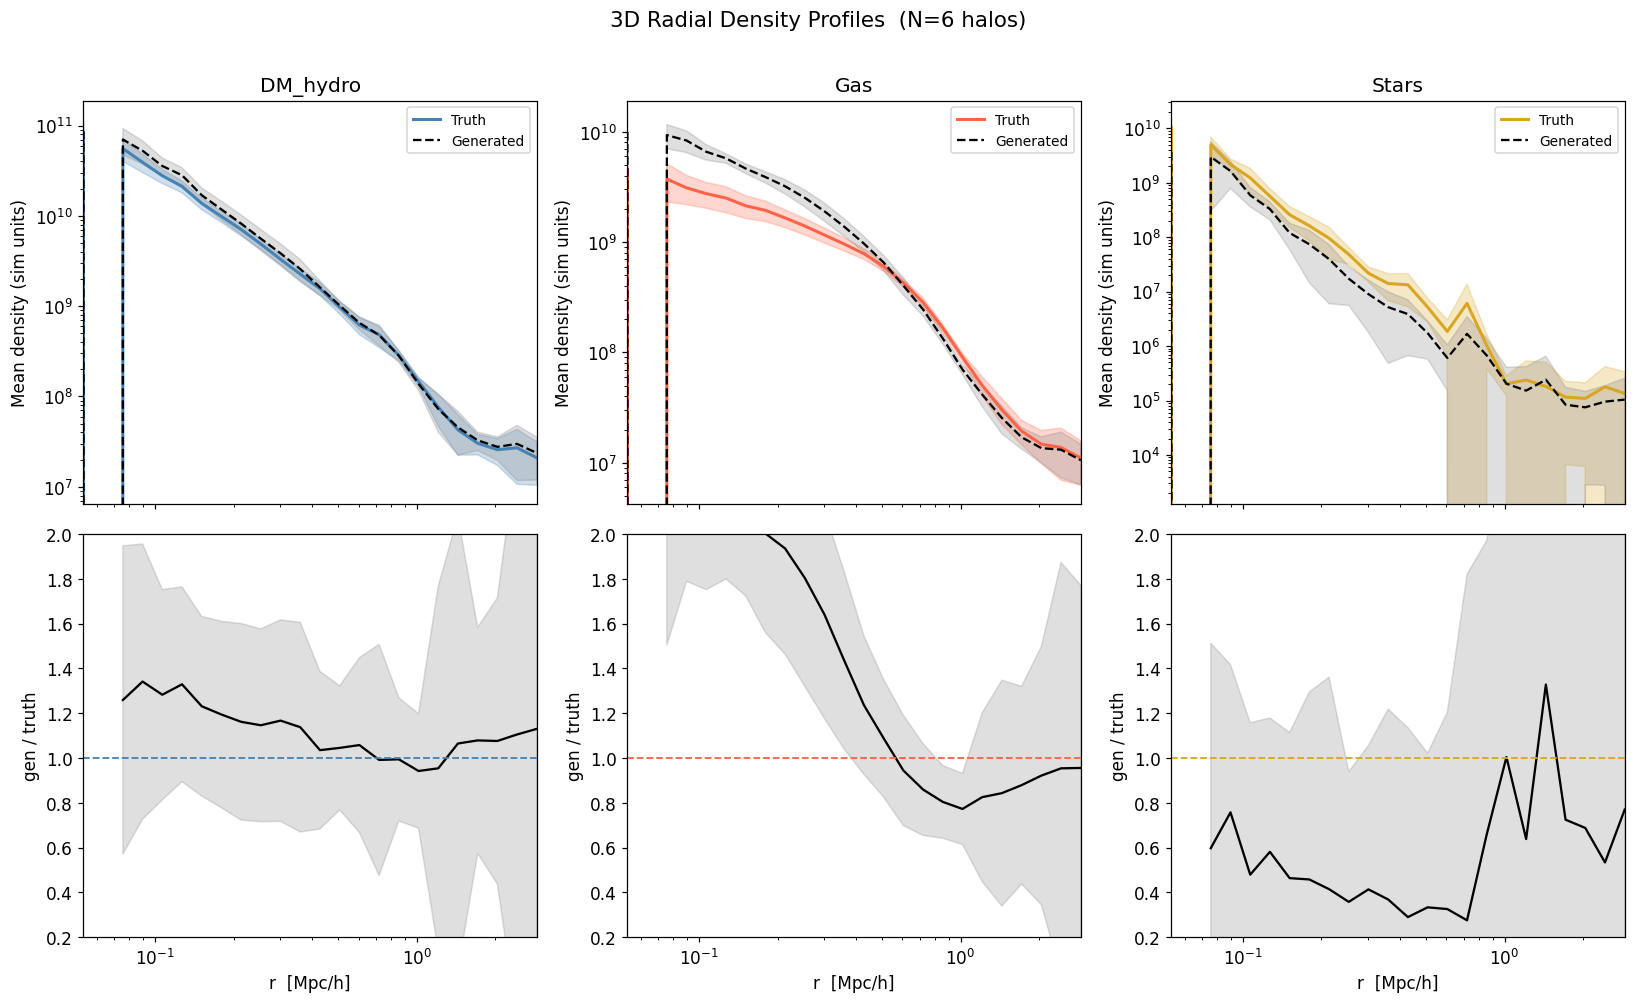

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex='col')

for ci, (ch, col) in enumerate(zip(CHANNEL_NAMES, CH_COLORS)):
    pg = prof_gen[ch]    # (N_VIS, n_bins)
    pt = prof_truth[ch]

    pg_m, pg_s = pg.mean(0), pg.std(0)
    pt_m, pt_s = pt.mean(0), pt.std(0)

    # ── Top: mean density profiles ────────────────────────────────────────────
    ax = axes[0, ci]
    ax.fill_between(r_mpc, pt_m - pt_s, pt_m + pt_s, alpha=0.25, color=col)
    ax.fill_between(r_mpc, pg_m - pg_s, pg_m + pg_s, alpha=0.25, color='gray')
    ax.plot(r_mpc, pt_m, color=col,   lw=2, label='Truth')
    ax.plot(r_mpc, pg_m, color='k',   lw=1.5, ls='--', label='Generated')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel('Mean density (sim units)')
    ax.set_title(ch)
    ax.legend(fontsize=9)
    # Annotate with the inner r limit
    ax.set_xlim(r_mpc[0], r_mpc[-1])

    # ── Bottom: ratio gen / truth ──────────────────────────────────────────────
    ax = axes[1, ci]
    safe = np.where(pt_m > 0, pt_m, np.nan)
    ratio = pg_m / safe
    ratio_err = (pg_s + pt_s) / (safe + 1e-30)
    ax.fill_between(r_mpc, ratio - ratio_err, ratio + ratio_err,
                    alpha=0.25, color='gray')
    ax.plot(r_mpc, ratio, color='k', lw=1.5)
    ax.axhline(1.0, color=col, lw=1.2, ls='--')
    ax.set_xscale('log')
    ax.set_ylim(0.2, 2.0)
    ax.set_xlabel('r  [Mpc/h]')
    ax.set_ylabel('gen / truth')
    ax.set_xlim(r_mpc[0], r_mpc[-1])

fig.suptitle(f'3D Radial Density Profiles  (N={N_VIS} halos)', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 5 — 3D Power Spectra  P(k)

In [7]:
def power_spectrum_3d(volume: np.ndarray, box_size: float = BOX_SIZE,
                      threads: int = 4) -> tuple[np.ndarray, np.ndarray]:
    """3D monopole P(k) via Pylians PKL.Pk.

    Converts *volume* to overdensity  delta = field/mean - 1.
    Returns k [h/Mpc] and P(k) [(Mpc/h)^3].
    If the field mean is zero (fully empty), returns (None, None).
    """
    field = np.ascontiguousarray(volume, dtype=np.float32)
    mu = field.mean()
    if mu <= 0:
        return None, None
    delta = field / mu - 1.0
    pk_obj = PKL.Pk(delta, box_size, 0, 'None', threads)
    k   = np.asarray(pk_obj.k3D,    dtype=np.float64)
    pk  = np.asarray(pk_obj.Pk[:,0], dtype=np.float64)   # monopole
    return k, pk


# ── Compute P(k) for the vis subset (this takes a moment) ────────────────────
pk_gen   = {ch: [] for ch in CHANNEL_NAMES}
pk_truth = {ch: [] for ch in CHANNEL_NAMES}
k_ref    = None

for i in tqdm(range(N_VIS), desc='P(k)'):
    for ci, ch in enumerate(CHANNEL_NAMES):
        k, pg = power_spectrum_3d(vis_gen[i, ci])
        _, pt = power_spectrum_3d(vis_truth[i, ci])
        if pg is not None and pt is not None:
            if k_ref is None:
                k_ref = k
            pk_gen[ch].append(pg)
            pk_truth[ch].append(pt)

# Convert to arrays
for ch in CHANNEL_NAMES:
    pk_gen[ch]   = np.array(pk_gen[ch])
    pk_truth[ch] = np.array(pk_truth[ch])

print('P(k) computed. k bins:', len(k_ref) if k_ref is not None else 'N/A')

P(k):   0%|          | 0/6 [00:00<?, ?it/s]


Computing power spectrum of the field...
Time to complete loop = 0.06
Time taken = 0.08 seconds

Computing power spectrum of the field...
Time to complete loop = 0.06
Time taken = 0.07 seconds

Computing power spectrum of the field...
Time to complete loop = 0.06
Time taken = 0.06 seconds

Computing power spectrum of the field...
Time to complete loop = 0.06
Time taken = 0.06 seconds

Computing power spectrum of the field...
Time to complete loop = 0.06
Time taken = 0.06 seconds

Computing power spectrum of the field...
Time to complete loop = 0.06
Time taken = 0.06 seconds

Computing power spectrum of the field...
Time to complete loop = 0.06
Time taken = 0.06 seconds

Computing power spectrum of the field...
Time to complete loop = 0.06
Time taken = 0.06 seconds

Computing power spectrum of the field...
Time to complete loop = 0.06
Time taken = 0.06 seconds

Computing power spectrum of the field...
Time to complete loop = 0.06
Time taken = 0.06 seconds

Computing power spectrum of t

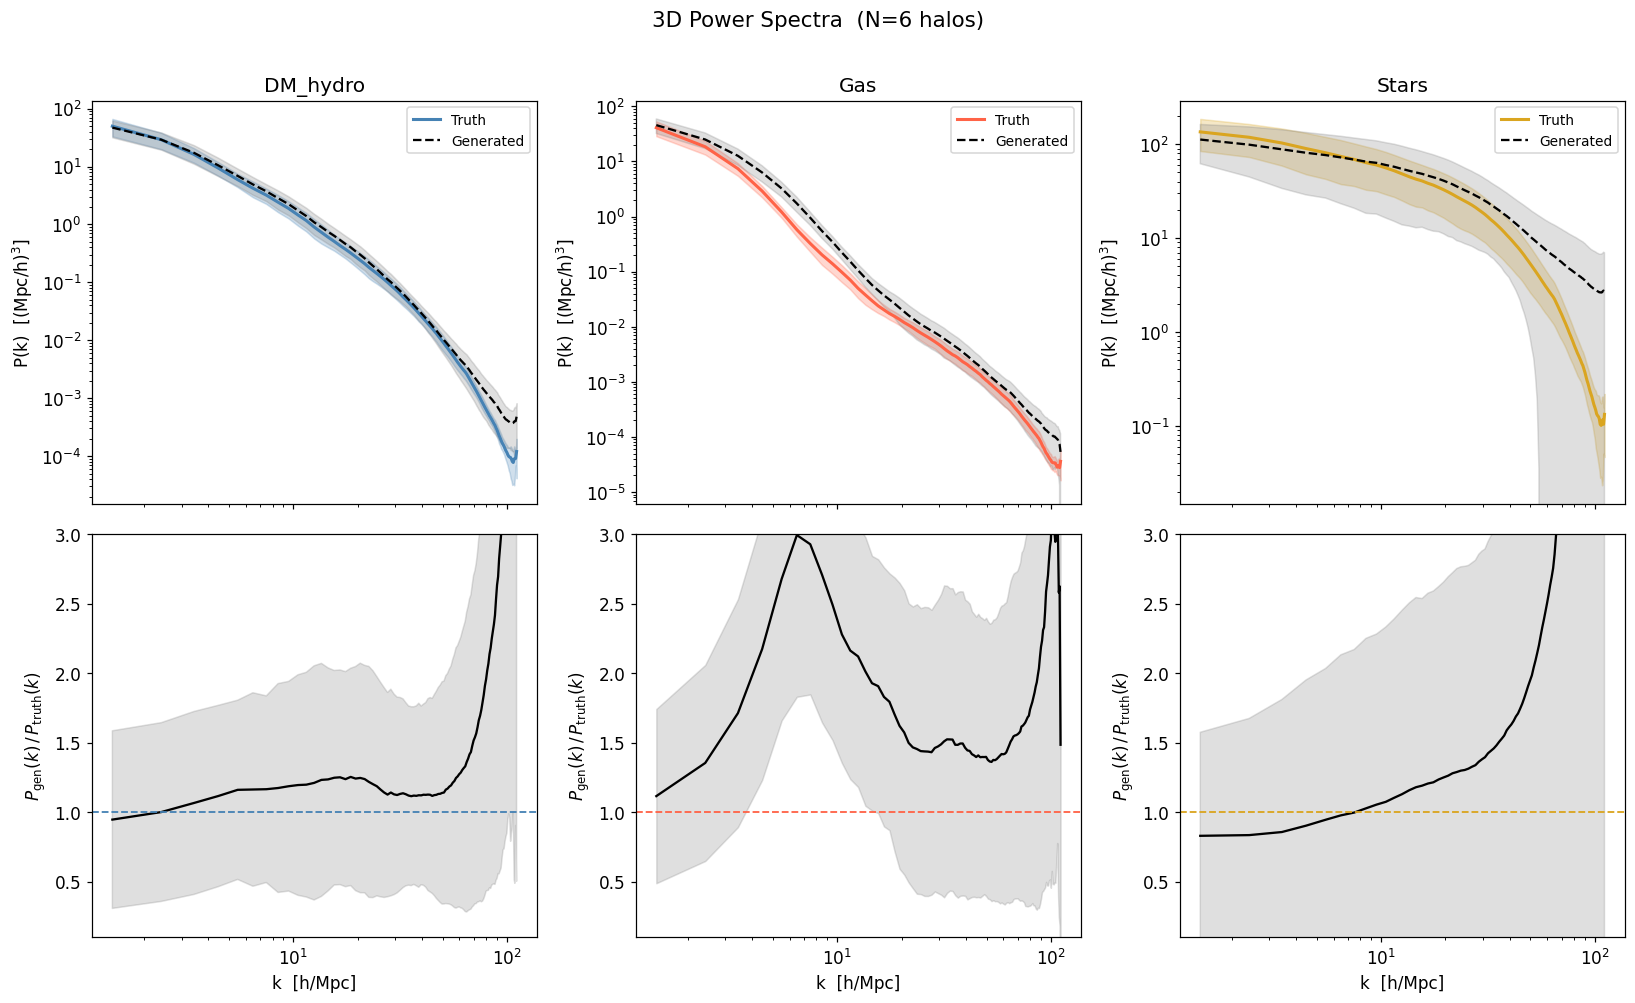

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex='col')

for ci, (ch, col) in enumerate(zip(CHANNEL_NAMES, CH_COLORS)):
    pg_arr = pk_gen[ch]    # (N, n_k)
    pt_arr = pk_truth[ch]

    if len(pg_arr) == 0:
        for row in range(2):
            axes[row, ci].set_visible(False)
        continue

    pg_m, pg_s = pg_arr.mean(0), pg_arr.std(0)
    pt_m, pt_s = pt_arr.mean(0), pt_arr.std(0)

    # ── Top: P(k) ────────────────────────────────────────────────────────────
    ax = axes[0, ci]
    ax.fill_between(k_ref, pt_m - pt_s, pt_m + pt_s, alpha=0.25, color=col)
    ax.fill_between(k_ref, pg_m - pg_s, pg_m + pg_s, alpha=0.25, color='gray')
    ax.loglog(k_ref, pt_m, color=col, lw=2,   label='Truth')
    ax.loglog(k_ref, pg_m, color='k', lw=1.5, ls='--', label='Generated')
    ax.set_ylabel(r'P(k)  [(Mpc/h)$^3$]')
    ax.set_title(ch)
    ax.legend(fontsize=9)

    # ── Bottom: ratio ─────────────────────────────────────────────────────────
    ax = axes[1, ci]
    safe   = np.where(pt_m > 0, pt_m, np.nan)
    ratio  = pg_m / safe
    r_err  = (pg_s + pt_s) / (safe + 1e-30)
    ax.fill_between(k_ref, ratio - r_err, ratio + r_err, alpha=0.25, color='gray')
    ax.semilogx(k_ref, ratio, color='k', lw=1.5)
    ax.axhline(1.0, color=col, lw=1.2, ls='--')
    ax.set_xlabel(r'k  [h/Mpc]')
    ax.set_ylabel(r'$P_\mathrm{gen}(k)\,/\,P_\mathrm{truth}(k)$')
    ax.set_ylim(0.1, 3.0)

fig.suptitle(f'3D Power Spectra  (N={N_VIS} halos)', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 6 — Shape Comparison (Reduced Inertia Tensor)

For each halo volume we compute the **reduced inertia tensor** (mass-weighted,
$r^{-2}$-normalized) and extract the axis ratios:

$$\tilde{I}_{ij} = \frac{\sum_k \rho_k \,\hat{x}_{k,i}\hat{x}_{k,j}}{r_k^2}, \qquad r_k = |\hat{\mathbf{x}}_k|$$

Eigenvalues $\lambda_1 \geq \lambda_2 \geq \lambda_3$ → semi-axes $a = \sqrt{\lambda_1} \geq b \geq c$.

Axis ratios: $q = b/a$, $s = c/a$.  Triaxiality: $T = (a^2 - b^2)/(a^2 - c^2)$ ($T=1$: prolate, $T=0$: oblate).

In [9]:
def inertia_shape(volume: np.ndarray) -> tuple[float, float, float]:
    """Compute axis ratios (q, s) and triaxiality T from reduced inertia tensor.

    Returns (q=b/a, s=c/a, T) where a>=b>=c are the semi-axes.
    Returns (nan, nan, nan) if the volume is empty or the matrix is degenerate.
    """
    D, H, W = volume.shape
    zz = np.arange(D, dtype=np.float32) - D / 2
    yy = np.arange(H, dtype=np.float32) - H / 2
    xx = np.arange(W, dtype=np.float32) - W / 2
    z3, y3, x3 = np.meshgrid(zz, yy, xx, indexing='ij')

    mass = volume.ravel().astype(np.float64)
    if mass.sum() == 0:
        return np.nan, np.nan, np.nan

    coords = np.stack([x3.ravel(), y3.ravel(), z3.ravel()], dtype=np.float64)  # (3, N)
    r2 = (coords**2).sum(0)
    r2_safe = np.maximum(r2, 1e-8)
    w = mass / r2_safe

    I = np.einsum('in,jn,n->ij', coords, coords, w)  # (3, 3)
    eigvals = np.linalg.eigvalsh(I)
    eigvals = np.sort(eigvals)[::-1]                  # descending
    eigvals = np.maximum(eigvals, 0.0)
    a2, b2, c2 = eigvals
    a = np.sqrt(a2)
    b = np.sqrt(b2)
    c = np.sqrt(c2)

    q = b / (a + 1e-30)
    s = c / (a + 1e-30)
    T = (a2 - b2) / (a2 - c2 + 1e-30) if (a2 - c2) > 1e-10 else 0.5
    return float(q), float(s), float(T)


# ── Compute shapes across ALL pairs ──────────────────────────────────────────
shape_gen   = {ch: {'q': [], 's': [], 'T': []} for ch in CHANNEL_NAMES}
shape_truth = {ch: {'q': [], 's': [], 'T': []} for ch in CHANNEL_NAMES}

for gp, sp in tqdm(pairs, desc='Shapes'):
    g, t, _ = load_pair(gp, sp)
    for ci, ch in enumerate(CHANNEL_NAMES):
        q_g, s_g, T_g = inertia_shape(g[ci])
        q_t, s_t, T_t = inertia_shape(t[ci])
        shape_gen[ch]['q'].append(q_g)
        shape_gen[ch]['s'].append(s_g)
        shape_gen[ch]['T'].append(T_g)
        shape_truth[ch]['q'].append(q_t)
        shape_truth[ch]['s'].append(s_t)
        shape_truth[ch]['T'].append(T_t)

for ch in CHANNEL_NAMES:
    for k in ('q', 's', 'T'):
        shape_gen[ch][k]   = np.array(shape_gen[ch][k])
        shape_truth[ch][k] = np.array(shape_truth[ch][k])

Shapes:   0%|          | 0/332 [00:00<?, ?it/s]

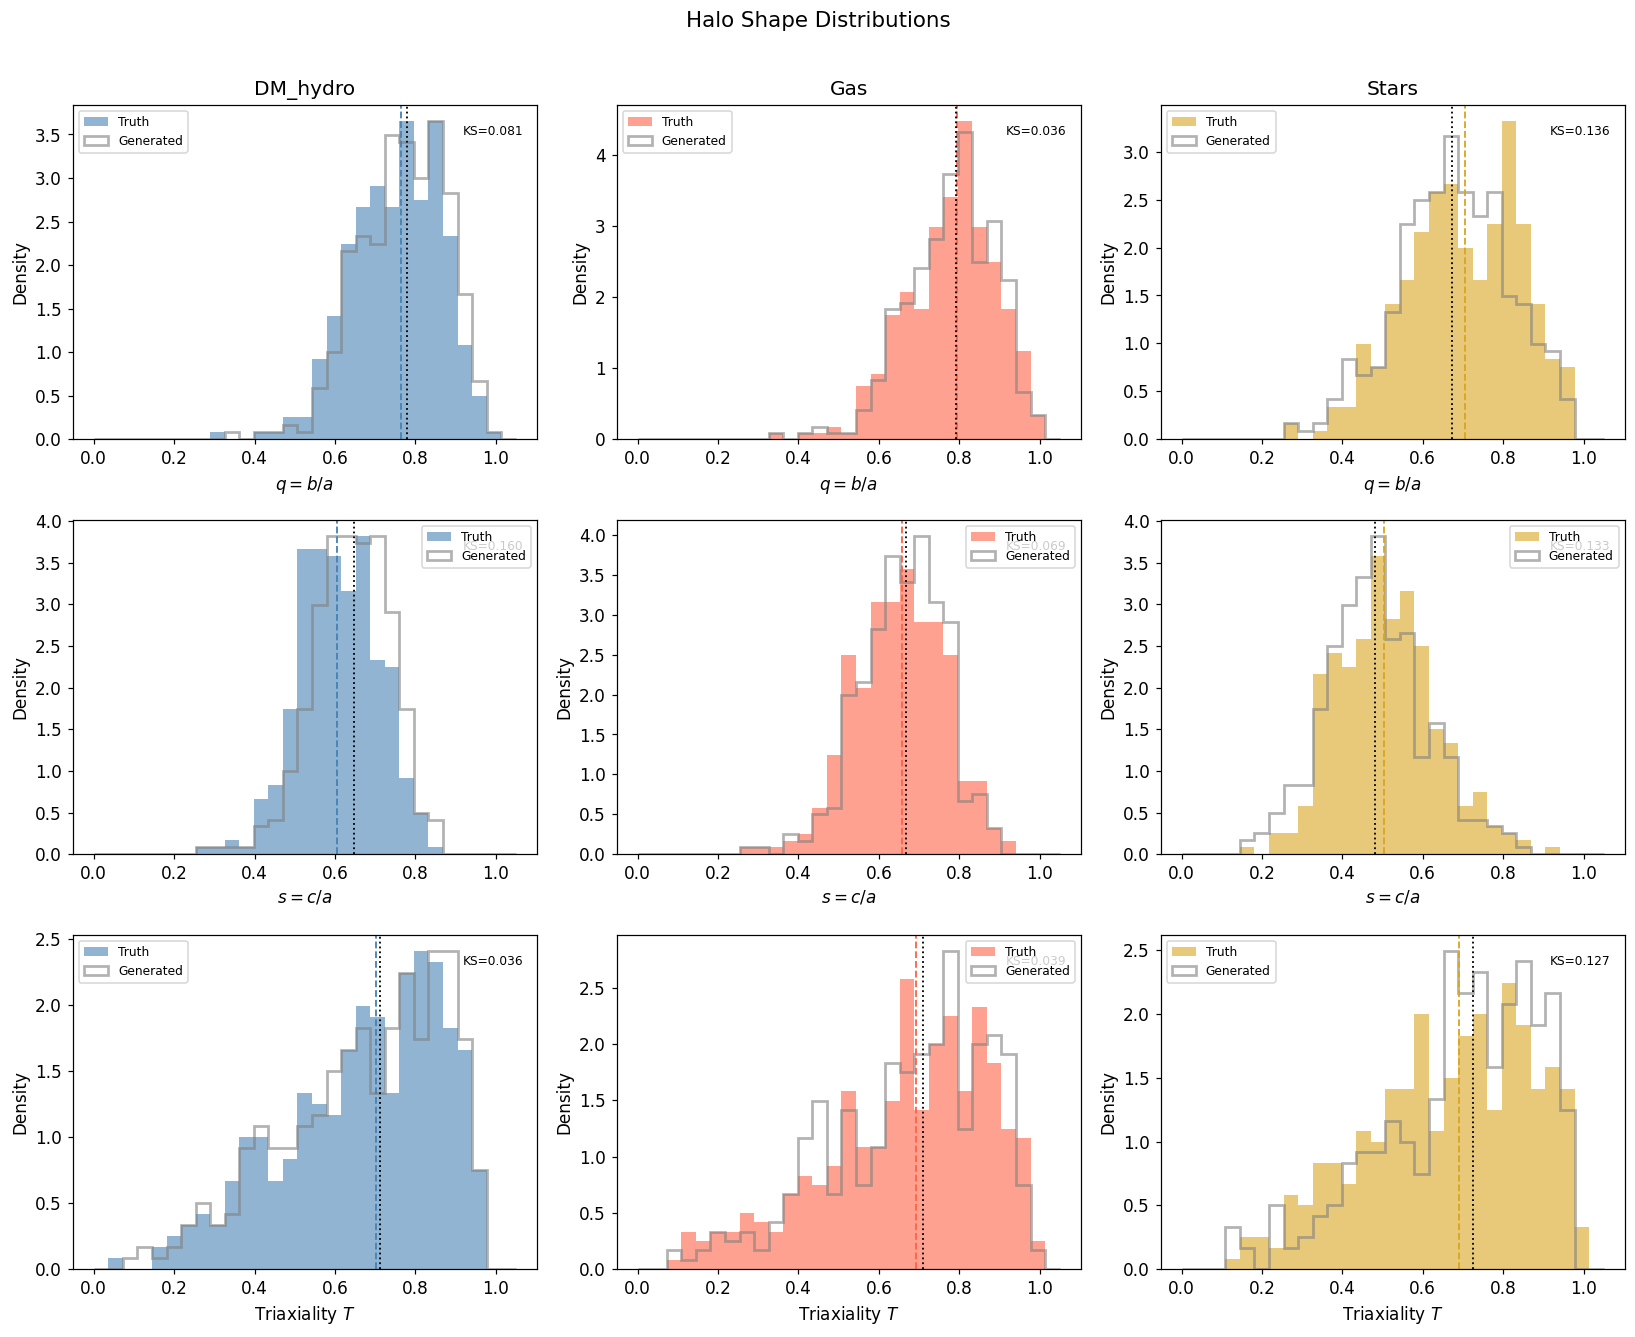

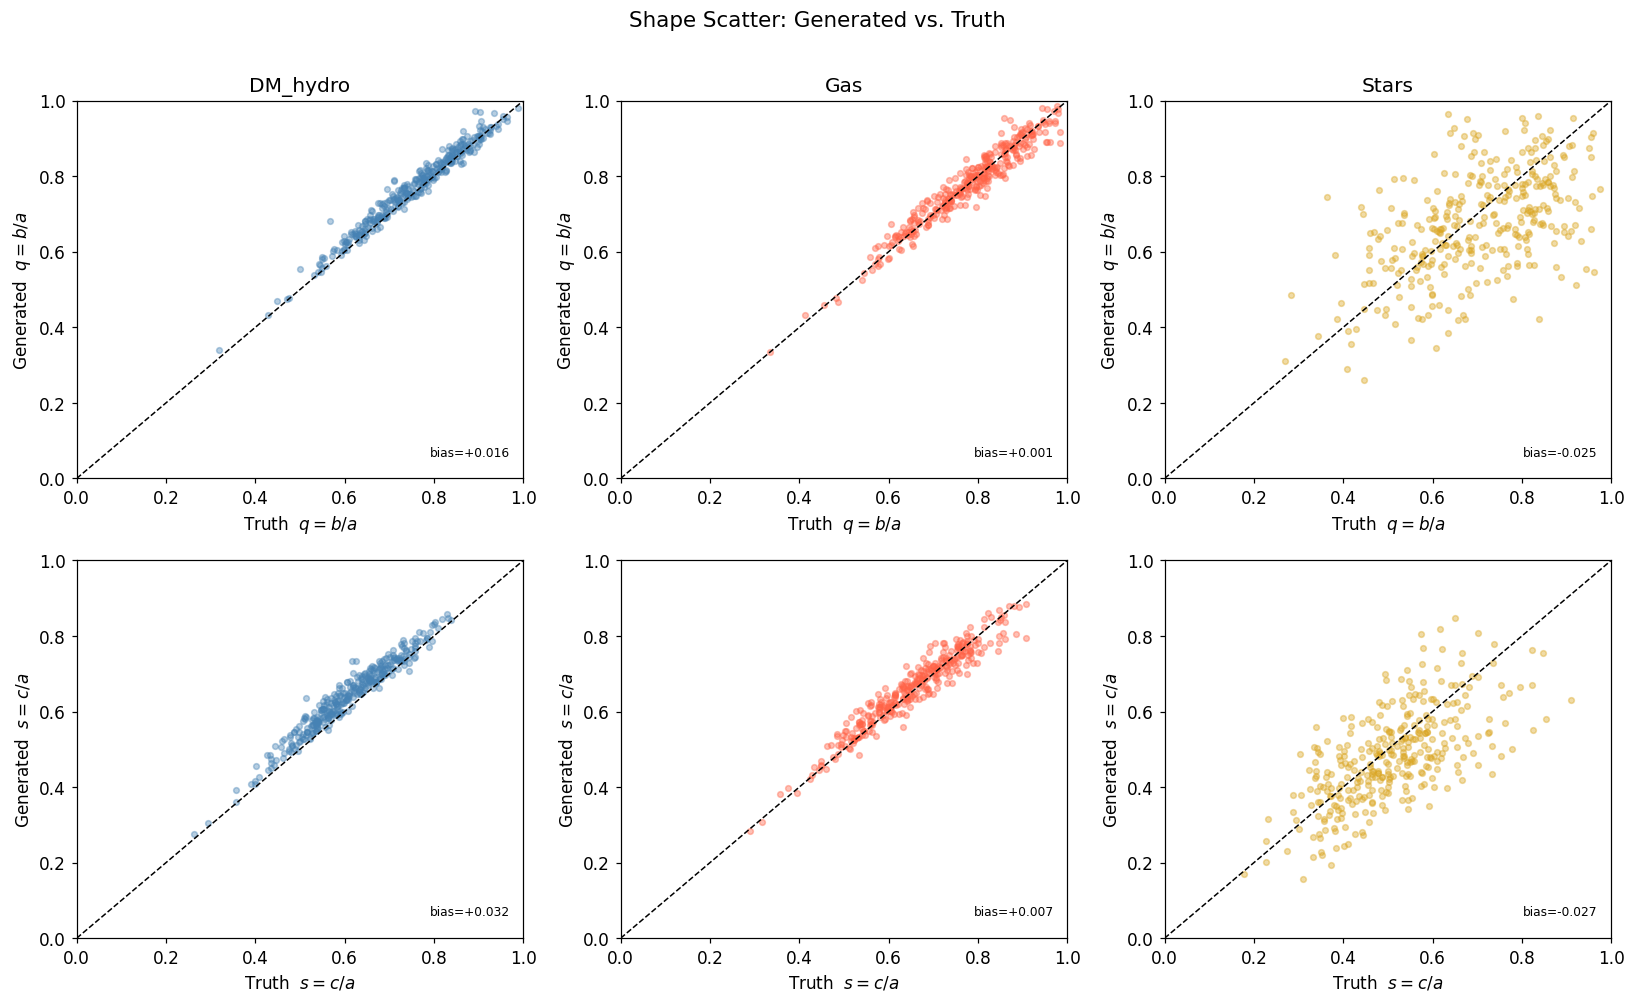

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

params_plot = [
    ('q', r'$q = b/a$', (0.0, 1.05)),
    ('s', r'$s = c/a$', (0.0, 1.05)),
    ('T', r'Triaxiality $T$', (0.0, 1.05)),
]

for ci, (ch, col) in enumerate(zip(CHANNEL_NAMES, CH_COLORS)):
    for ri, (key, label, xlim) in enumerate(params_plot):
        ax = axes[ri, ci]
        sg = shape_gen[ch][key]
        st = shape_truth[ch][key]

        # filter NaN
        valid = np.isfinite(sg) & np.isfinite(st)
        sg, st = sg[valid], st[valid]

        bins = np.linspace(xlim[0], xlim[1], 30)
        ax.hist(st, bins=bins, color=col, alpha=0.6, label='Truth', density=True)
        ax.hist(sg, bins=bins, color='gray', alpha=0.6, label='Generated',
                histtype='step', lw=1.8, density=True)
        ax.set_xlabel(label)
        ax.set_ylabel('Density')
        if ri == 0:
            ax.set_title(ch)
        ax.legend(fontsize=8)

        # Annotate medians
        ax.axvline(np.median(st), color=col,  lw=1.2, ls='--')
        ax.axvline(np.median(sg), color='k',  lw=1.2, ls=':')

        ks, pv = ks_2samp(st, sg)
        ax.text(0.97, 0.94, f'KS={ks:.3f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=8)

fig.suptitle('Halo Shape Distributions', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

# ── Scatter plots: gen vs truth for q and s ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ci, (ch, col) in enumerate(zip(CHANNEL_NAMES, CH_COLORS)):
    for ri, (key, label) in enumerate([('q', r'$q=b/a$'), ('s', r'$s=c/a$')]):
        ax = axes[ri, ci]
        sg = shape_gen[ch][key]
        st = shape_truth[ch][key]
        valid = np.isfinite(sg) & np.isfinite(st)
        ax.scatter(st[valid], sg[valid], alpha=0.4, s=14, color=col, rasterized=True)
        ax.plot([0, 1], [0, 1], 'k--', lw=1)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xlabel(f'Truth  {label}')
        ax.set_ylabel(f'Generated  {label}')
        if ri == 0:
            ax.set_title(ch)
        bias = (sg[valid] - st[valid]).mean()
        ax.text(0.97, 0.06, f'bias={bias:+.3f}', transform=ax.transAxes,
                ha='right', fontsize=8)
fig.suptitle('Shape Scatter: Generated vs. Truth', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 7 — Baryon Fraction Profile

$$f_\mathrm{bar}(r) = \frac{M_\mathrm{Gas}(r) + M_\mathrm{Stars}(r)}{M_\mathrm{DM}(r) + M_\mathrm{Gas}(r) + M_\mathrm{Stars}(r)}$$

Computed in spherical shells.  The dashed horizontal line marks the Planck 2018 cosmic
baryon fraction $f_b^{\rm cosmic} = \Omega_b / \Omega_m \approx 0.156$.

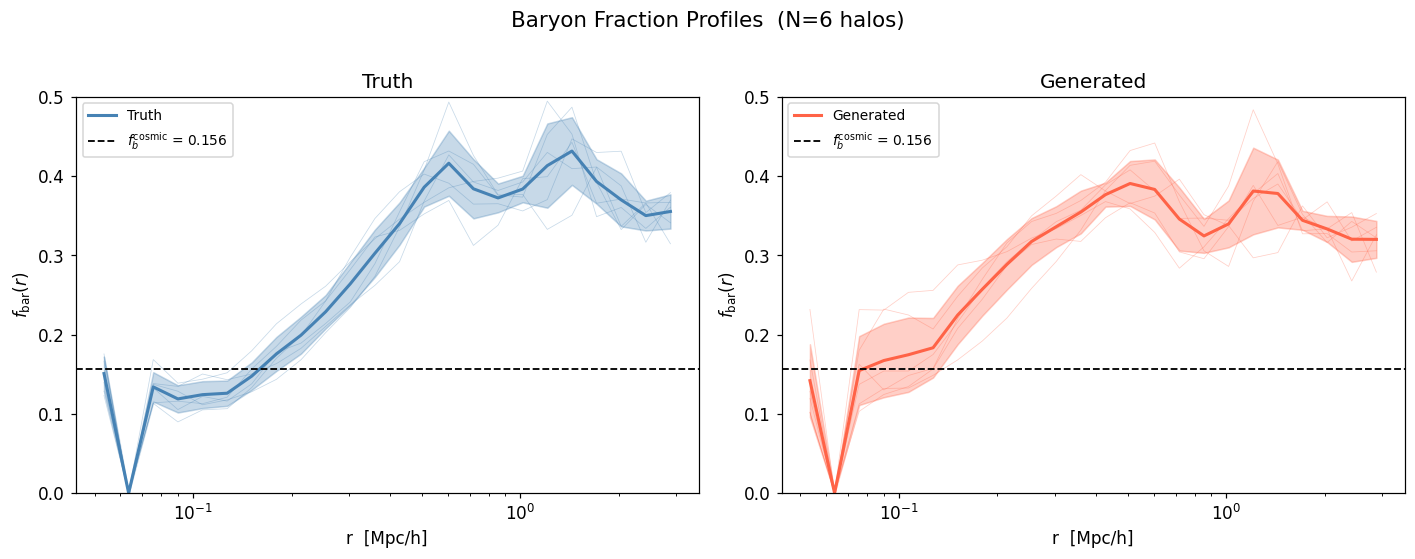

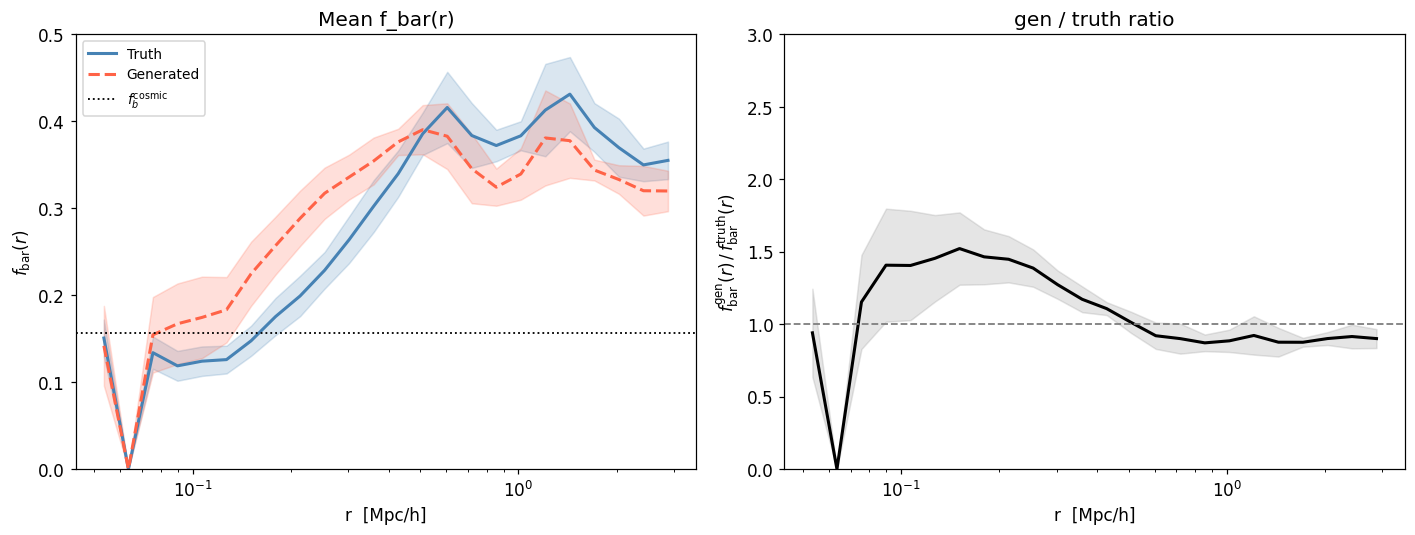

In [11]:
def baryon_fraction_profile(gen: np.ndarray, truth: np.ndarray,
                             n_bins: int = N_RADIAL_BINS,
                             logspace: bool = True):
    """Compute baryon fraction profile in spherical shells.

    Parameters
    ----------
    gen, truth : (3, D, H, W) – channels [DM_hydro, Gas, Stars]

    Returns
    -------
    r_pix : (n_bins,) radial bin centers in voxels
    fb_g  : (n_bins,) baryon fraction from generated
    fb_t  : (n_bins,) baryon fraction from truth
    """
    D, H, W = gen.shape[1:]
    zz = np.arange(D) - D / 2
    yy = np.arange(H) - H / 2
    xx = np.arange(W) - W / 2
    z3, y3, x3 = np.meshgrid(zz, yy, xx, indexing='ij')
    r = np.sqrt(x3**2 + y3**2 + z3**2)

    r_max = min(D, H, W) / 2.0
    if logspace:
        bins = np.logspace(np.log10(1.0), np.log10(r_max), n_bins + 1)
    else:
        bins = np.linspace(0, r_max, n_bins + 1)
    r_centers = 0.5 * (bins[:-1] + bins[1:])

    fb_g = np.zeros(n_bins)
    fb_t = np.zeros(n_bins)

    for i in range(n_bins):
        mask = (r >= bins[i]) & (r < bins[i + 1])
        if mask.sum() == 0:
            continue
        for arr, fb in [(gen, fb_g), (truth, fb_t)]:
            dm  = arr[0][mask].sum()
            gas = arr[1][mask].sum()
            st  = arr[2][mask].sum()
            tot = dm + gas + st
            fb[i] = (gas + st) / (tot + 1e-30)

    return r_centers, fb_g, fb_t


# ── Compute fb profiles over the vis subset ───────────────────────────────────
fb_gen_all   = []
fb_truth_all = []

for i in range(N_VIS):
    r_fb, fb_g, fb_t = baryon_fraction_profile(vis_gen[i], vis_truth[i])
    fb_gen_all.append(fb_g)
    fb_truth_all.append(fb_t)

fb_gen_all   = np.array(fb_gen_all)    # (N_VIS, n_bins)
fb_truth_all = np.array(fb_truth_all)
r_fb_mpc     = r_fb * PIX_SIZE

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (arr, label, col) in zip(
        axes,
        [(fb_truth_all, 'Truth', 'steelblue'),
         (fb_gen_all,   'Generated', 'tomato')]):
    m, s = arr.mean(0), arr.std(0)
    ax.fill_between(r_fb_mpc, m - s, m + s, alpha=0.3, color=col)
    ax.semilogx(r_fb_mpc, m, color=col, lw=2, label=label)
    for j in range(len(arr)):
        ax.semilogx(r_fb_mpc, arr[j], color=col, lw=0.5, alpha=0.3)
    ax.axhline(F_BAR_COSMIC, color='k', lw=1.2, ls='--',
               label=r'$f_b^{\rm cosmic}$' + f' = {F_BAR_COSMIC}')
    ax.set_xlabel('r  [Mpc/h]')
    ax.set_ylabel(r'$f_{\rm bar}(r)$')
    ax.set_title(label)
    ax.set_ylim(0, 0.5)
    ax.legend(fontsize=9)

fig.suptitle(f'Baryon Fraction Profiles  (N={N_VIS} halos)', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

# ── Overlay comparison ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for arr, label, col, ls in [
        (fb_truth_all, 'Truth', 'steelblue', '-'),
        (fb_gen_all,   'Generated', 'tomato', '--')]:
    m, s = arr.mean(0), arr.std(0)
    ax.fill_between(r_fb_mpc, m - s, m + s, alpha=0.2, color=col)
    ax.semilogx(r_fb_mpc, m, color=col, lw=2, ls=ls, label=label)
ax.axhline(F_BAR_COSMIC, color='k', lw=1.2, ls=':',
           label=r'$f_b^{\rm cosmic}$')
ax.set_xlabel('r  [Mpc/h]'); ax.set_ylabel(r'$f_{\rm bar}(r)$')
ax.set_title('Mean f_bar(r)'); ax.legend(fontsize=9); ax.set_ylim(0, 0.5)

ax = axes[1]
ratio = fb_gen_all.mean(0) / (fb_truth_all.mean(0) + 1e-30)
ax.semilogx(r_fb_mpc, ratio, color='k', lw=2)
ax.axhline(1.0, color='gray', ls='--', lw=1.2)
ax.fill_between(r_fb_mpc,
                ratio - fb_gen_all.std(0) / (fb_truth_all.mean(0) + 1e-30),
                ratio + fb_gen_all.std(0) / (fb_truth_all.mean(0) + 1e-30),
                alpha=0.2, color='gray')
ax.set_xlabel('r  [Mpc/h]')
ax.set_ylabel(r'$f_{\rm bar}^{\rm gen}(r) \,/\, f_{\rm bar}^{\rm truth}(r)$')
ax.set_title('gen / truth ratio')
ax.set_ylim(0.0, 3.0)

fig.tight_layout()
plt.show()

## 8 — Summary Statistics Table

In [ ]:
import pandas as pd

rows = []
for ci, ch in enumerate(CHANNEL_NAMES):
    er = rel_err[:, ci]

    # shape stats
    q_g = shape_gen[ch]['q'];  q_t = shape_truth[ch]['q']
    s_g = shape_gen[ch]['s'];  s_t = shape_truth[ch]['s']
    T_g = shape_gen[ch]['T'];  T_t = shape_truth[ch]['T']

    valid_q = np.isfinite(q_g) & np.isfinite(q_t)
    valid_s = np.isfinite(s_g) & np.isfinite(s_t)
    valid_T = np.isfinite(T_g) & np.isfinite(T_t)

    # KS on log-masses
    mt = mass_truth[:, ci]; mg = mass_gen[:, ci]
    mask_m = (mt > 0) & (mg > 0)
    ks_m, _ = ks_2samp(np.log10(mt[mask_m]), np.log10(mg[mask_m]))

    rows.append({
        'Channel': ch,
        'Mass Δ mean [%]': f'{er.mean()*100:+.1f}',
        'Mass Δ σ [%]':    f'{er.std()*100:.1f}',
        'Mass KS':         f'{ks_m:.3f}',
        'q bias (gen-truth)': f'{(q_g[valid_q]-q_t[valid_q]).mean():+.3f}',
        'q KS':            f'{ks_2samp(q_t[valid_q], q_g[valid_q])[0]:.3f}',
        's bias (gen-truth)': f'{(s_g[valid_s]-s_t[valid_s]).mean():+.3f}',
        's KS':            f'{ks_2samp(s_t[valid_s], s_g[valid_s])[0]:.3f}',
        'T bias (gen-truth)': f'{(T_g[valid_T]-T_t[valid_T]).mean():+.3f}',
    })

df = pd.DataFrame(rows).set_index('Channel')
print(df.to_string())
df